# How can machine learning be applied to predict site to classify site stability of carbon storage basins?

In my second subquestion, I use a dataset from Miocic et al. (2016) of global CGS basins. 

# Import Necessary Packages

In [114]:
#basic operations
import pandas as pd
import numpy as np

#PCA
from sklearn.decomposition import PCA

#plotting
import matplotlib.pyplot as plt
import seaborn as sns

#modeling
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, recall_score, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#warnings
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings('ignore', category=UndefinedMetricWarning)

# Read in Data from Miocic et al. (2016)
I read in the dataframe that I previously created using Miocic et al. (2016).

In [14]:
miocic = pd.read_csv('miocic_df.csv').set_index('Name')
miocic 

,Densities,Leakage,Reservoir thickness (Gross),Seal thickness,Depth,Temperature,Pressure,Trapmech_structural,Trapmech_stratigraphic,Structural_fault,...,Res_sandstone,Res_carbonates,Res_other,Carbonate_limestone,Carbonate_dolomite,Seal_shale,Seal_evaporite,Seal_other,Stacked_yes,Stacked_nan
Name,,,,,,,,,,,,,,,,,,,,,
Jackson Dome,654.6,0.0,214.4,900.0,4660.00,150.000000,491.6,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
El Trapial Field,141.0,0.0,163.4,210.0,1234.00,56.000000,64.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.8,0.2,0.4,0.0,1.0
Messokampos,0.9,1.0,260.0,10.0,500.00,25.000000,0.5,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
Budafa Field,451.6,0.0,100.0,420.0,3300.00,164.000000,295.0,1.0,0.2,0.4,...,1.0,0.0,0.0,0.0,0.0,1.0,0.2,0.2,1.0,0.0
DF1-1 Field,378.3,0.0,190.4,210.0,1365.00,70.000000,129.2,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Turaco, Albertine Graben",769.4,0.0,166.0,266.0,2500.00,87.667043,288.8,0.8,0.2,0.4,...,1.0,0.0,0.0,0.0,0.0,0.8,0.2,0.0,1.0,0.0
DF29-1,465.2,0.0,80.0,300.0,1837.00,92.000000,186.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
L22-1,423.8,0.0,121.7,300.0,1498.00,78.000000,138.8,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


# Principal Component Analysis

Principal Component Analysis (PCA) is a method of unsupervised machine learning which maximizes variance and important information from a table by creating principal components of a linear combination of features. This is typically performed on inter-correlated data with linearly dependent features.

I perform PCA using the data’s features and withhold data labels (leakage presence/absence). This enables the model to reveal inherent structures within the data to potentially partition the sites based on certain characteristics without explicit training.

In order to perform PCA, I need to reorient the data to be a 61 x 22 numpy array. I also only want to include the data, not the Leakage information. I create miocic_pca_arr which is a numpy array of the miocic dataframe only containing feature information, not leakage/stability.

In [15]:
miocic_pca = miocic.drop(columns= 'Leakage')
miocic_pca_arr = miocic_pca.to_numpy()
miocic_pca_arr.shape

(61, 22)

Next, I calculate the mean and standard deviation across each column/feature in order to center and standardize the numpy array. This is essential in PCA because it prevents percieved feature importance due to size of numbers alone. This way, features are standardized across different scales, allowing PCA to identify key features not considering conflated number values.

In [16]:
miocic_mean = np.mean(miocic_pca_arr, axis=0)
miocic_std = np.std(miocic_pca_arr, axis=0)
miocic_standardized = (miocic_pca_arr - miocic_mean) / miocic_std

In [17]:
pca = PCA()
pca.fit(miocic_standardized)
miocic_2d= pca.transform(miocic_standardized)[:, :2]

## Visualize Principal Components
In order to visualize the PCA, I plot the transformed data using the first two principal components as the x and y axis. I color the data based on the Leakage target variable.

In [18]:
hue = miocic['Leakage'].map({0: 'No Leakage (Stable)',
                            1: 'Leakage Detected (Insecure)',
                            2: 'Ambiguous'})
palette = {'No Leakage (Stable)': '#1f77b4', # '#4C72B0', # '#1f77b4'
           'Leakage Detected (Insecure)': 'red',
           'Ambiguous': '#4D4D4D'}

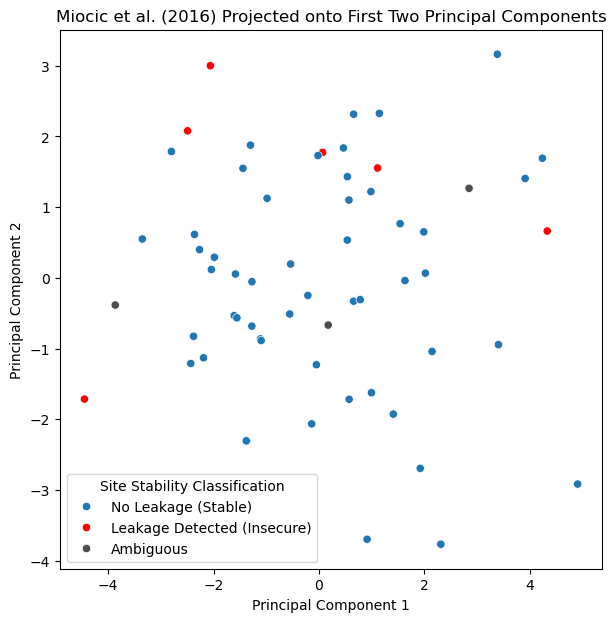

In [19]:
plt.figure(figsize = (7, 7))
plt.title("Miocic et al. (2016) Projected onto First Two Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
ax = sns.scatterplot(x = miocic_2d[:, 0], y = miocic_2d[:, 1], hue = hue, palette = palette)
ax.legend(title='Site Stability Classification');

Site Stability Class seems uncorrelated with Principal Component 1 and Principal Component 2. A majority of insecure sites  have large Principal Component 2 values; however, stable sites are spatially distributed around insecure sites. PCA fails to spatially separate sites based on site stability. 

## PCA Analysis
To further determine the success of the PCA, I calculate the percent of total dataset variance captured by the first two principal components.

In [20]:
print(f'Percent Variance Captured: {sum(pca.explained_variance_ratio_[0:2])*100}')

Percent Variance Captured: 31.11081781438656


Only 31% of variance is captured using the first two principal components, demonstrating large variance loss.
## Scree Plot
Next, I create a Scree Plot to visualize the weight of each principal component.

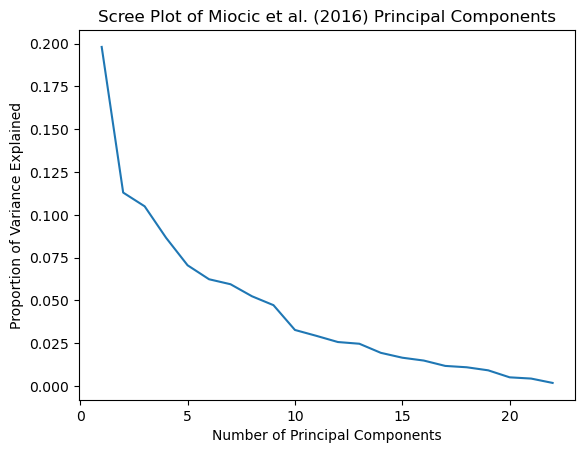

In [21]:
x= np.arange(1, 23)
y = pca.explained_variance_ratio_
plt.plot(x, y)
plt.xlabel('Number of Principal Components')
plt.ylabel('Proportion of Variance Explained')
plt.title('Scree Plot of Miocic et al. (2016) Principal Components')
plt.show()

# Site Stability Classification 
First, I remove basins where leakage detection was inconclusive. Aviso et al. (2019) re-classified these points as leakage. However, I chose to remove them instead because if they are stable they could influence the model.

In [48]:
miocic['Leakage'] = miocic['Leakage'].map({0.0:0.0, 1.0:1.0, 2.0: 1.0})
miocic['Leakage'].value_counts()

Leakage
0.0    52
1.0     9
Name: count, dtype: int64

I define X and y and create a stratified 70:30 train test split, ensuring that both classes are present in the train and test splits.

In [50]:
#define X (all data except for leakage classification)
X = miocic.drop(columns='Leakage')

#define y 
y = miocic['Leakage']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state =22, stratify= y) 

## Random Forest Classifier

In [52]:
#without hyperparameter tuning
rf = RandomForestClassifier(random_state=22)
rf.fit(X_train, y_train)
y_pred_rf= rf.predict(X_test)
rf.score(X_test, y_test)

0.8421052631578947

In [53]:
f1_score(y_test, y_pred_rf)

0.0

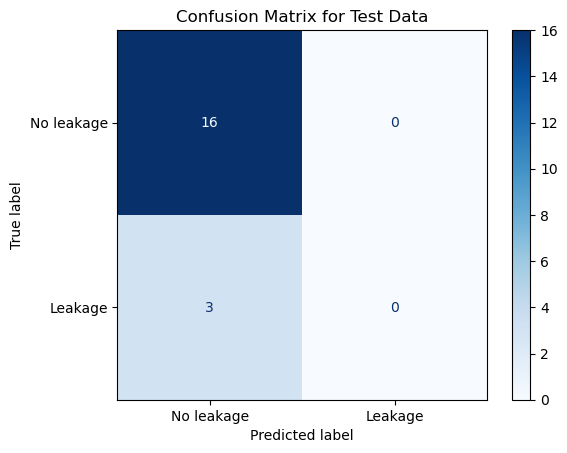

In [57]:
cm = confusion_matrix(y_test, y_pred_rf, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No leakage','Leakage'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Test Data")
plt.show()

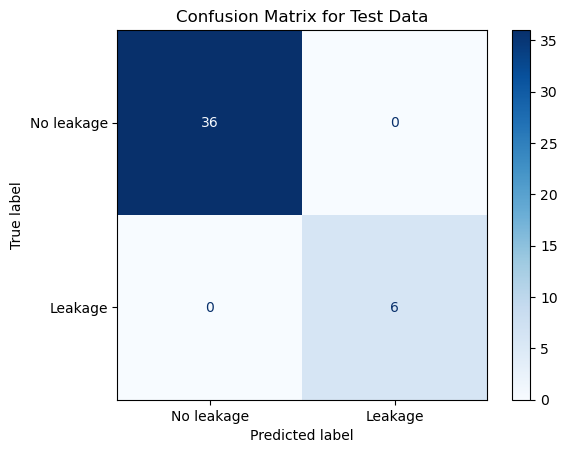

In [58]:
cm = confusion_matrix(y_train, rf.predict(X_train), labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No leakage','Leakage'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Test Data")
plt.show()

In [61]:
f1_score(y_train, rf.predict(X_train))

0.9230769230769231

In [105]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=22)
hyperparameters = {
    'n_estimators': [200, 400],
    'max_depth': [None, 20],
    'min_samples_leaf': [1, 3],
    'max_features': ['sqrt', 0.5],
    'class_weight': ['balanced', 'balanced_subsample']}
rf= GridSearchCV(
    estimator = RandomForestClassifier(random_state=22),
    param_grid = hyperparameters,
    scoring={'precision': 'precision', 
        'recall': 'recall',
        'f1': 'f1'},
    refit='recall', 
    cv=cv,
    return_train_score= True)
rf.fit(X_train, y_train)
probs = rf.predict_proba(X_train)[:, 1]

In [131]:
#optimize threshold using validation data
probs = cross_val_predict(
    rf.best_estimator_,
    X_train, y_train,
    cv=cv,
    method='predict_proba')[:, 1]
precision, recall, thresholds = precision_recall_curve(y_train, probs)
f1_scores = (2 * precision * recall) / (precision + recall + 1e-9)

accuracies = []
for t in thresholds:
    preds = (probs >= t).astype(int)
    accuracies.append(accuracy_score(y_train, preds))
accuracies = np.array(accuracies)

# Normalize to 0-1
f1_norm       = f1_scores[:-1] / (f1_scores[:-1].max() + 1e-9)
accuracy_norm = accuracies / (accuracies.max() + 1e-9)

# Adjust weights as needed
combined = (0.8 * accuracy_norm) + (0.2 * f1_norm) 

best_threshold = thresholds[combined.argmax()]
print('Best threshold: ', best_threshold)

Best threshold:  0.28146799846807835


In [132]:
train_probs = rf.predict_proba(X_train)[:, 1]
train_preds_rf = (train_probs >= best_threshold).astype(int)
test_probs = rf.predict_proba(X_test)[:, 1]
test_preds_rf = (test_probs >= best_threshold).astype(int)
    
print('Train Accuracy: ', accuracy_score(y_train, train_preds_rf))       
#print('Test Accuracy: ', accuracy_score(y_test,  test_preds_rf,))  
print('Train F1: ', f1_score(y_train, train_preds_rf, average='binary', zero_division=0))
#print('Test F1: ', f1_score(y_test,  test_preds_rf,  average='binary', zero_division=0)) 

Train Accuracy:  0.8809523809523809
Train F1:  0.7058823529411765


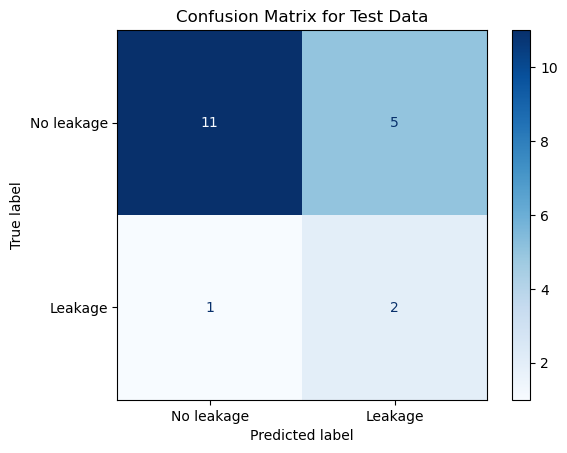

In [128]:
cm = confusion_matrix(y_test, test_preds_rf, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No leakage','Leakage'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Test Data")
plt.show()

In [135]:
#AI SLOP
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve, accuracy_score, f1_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=22)

fold_thresholds = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Fit and predict on validation fold
    rf.best_estimator_.fit(X_tr, y_tr)
    probs_val = rf.best_estimator_.predict_proba(X_val)[:, 1]
    
    # Find best threshold for this fold
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, probs_val)
    f1_scores = (2 * precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-9)
    
    accuracies = []
    for t in thresholds:
        preds = (probs_val >= t).astype(int)
        accuracies.append(accuracy_score(y_val, preds))
    accuracies = np.array(accuracies)
    
    f1_norm       = f1_scores[:-1] / (f1_scores[:-1].max() + 1e-9)
    accuracy_norm = accuracies / (accuracies.max() + 1e-9)
    combined      = (0.5 * accuracy_norm) + (0.5 * f1_norm)
    
    best_t = thresholds[combined.argmax()]
    fold_thresholds.append(best_t)
    
    # Evaluate this fold at its best threshold
    preds_best = (probs_val >= best_t).astype(int)
    print(f"Fold {fold+1} | Threshold: {best_t:.2f} | Accuracy: {accuracy_score(y_val, preds_best):.2f} | F1: {f1_score(y_val, preds_best, zero_division=0):.2f}")

# Average threshold across folds
best_threshold = np.mean(fold_thresholds)
print(f'\nMean threshold across folds: {best_threshold:.2f}')

Fold 1 | Threshold: 0.56 | Accuracy: 1.00 | F1: 1.00
Fold 2 | Threshold: 0.25 | Accuracy: 1.00 | F1: 1.00
Fold 3 | Threshold: 0.24 | Accuracy: 0.75 | F1: 0.50
Fold 4 | Threshold: 0.51 | Accuracy: 1.00 | F1: 1.00
Fold 5 | Threshold: 0.36 | Accuracy: 0.88 | F1: 0.67

Mean threshold across folds: 0.39


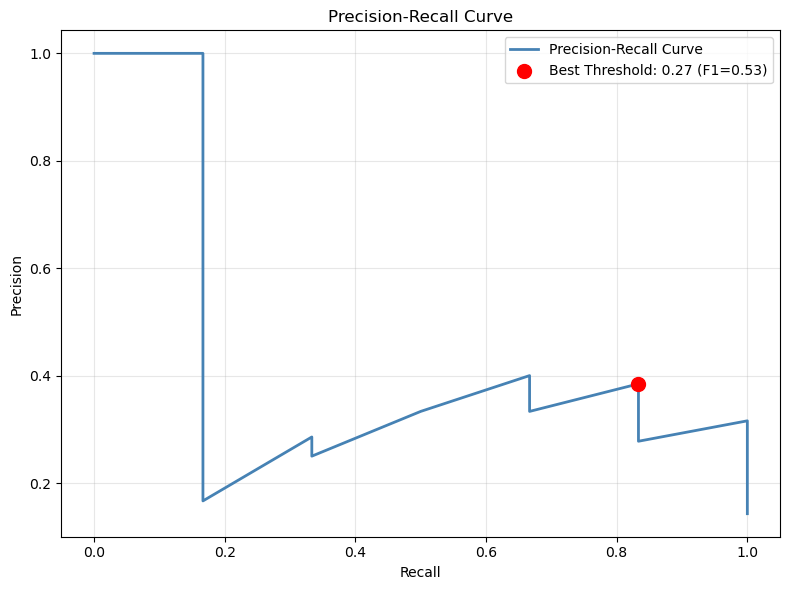

In [109]:
import matplotlib.pyplot as plt

precision_curve, recall_curve, thresholds = precision_recall_curve(y_train, probs_oof)
f1_scores = (2 * precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-9)
best_threshold = thresholds[f1_scores.argmax()]
best_idx = f1_scores.argmax()

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, color='steelblue', lw=2, label='Precision-Recall Curve')
plt.scatter(recall_curve[best_idx], precision_curve[best_idx], 
            color='red', zorder=5, s=100,
            label=f'Best Threshold: {best_threshold:.2f} (F1={f1_scores[best_idx]:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

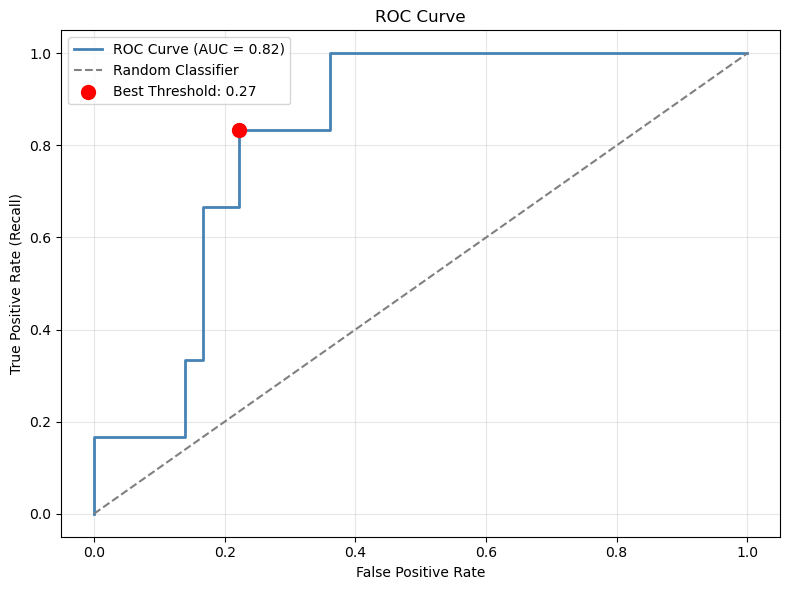

AUC: 0.82


In [110]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, roc_thresholds = roc_curve(y_train, probs_oof)
auc = roc_auc_score(y_train, probs_oof)

# Find closest threshold on ROC curve to our best threshold
best_roc_idx = (np.abs(roc_thresholds - best_threshold)).argmin()

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.scatter(fpr[best_roc_idx], tpr[best_roc_idx],
            color='red', zorder=5, s=100,
            label=f'Best Threshold: {best_threshold:.2f}')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC: {auc:.2f}')

In [ ]:
test_preds_rf = rf.predict(X_test)
train_preds_rf = rf.predict(X_train)
    
print('Train Accuracy: ', rf.score(X_train, y_train))       
print('Test Accuracy: ', rf.score(X_test, y_test))  
print('Train Recall: ', recall_score(y_train, train_preds_rf, zero_division=0))
print('Test Recall: ', recall_score(y_test,  test_preds_rf,  zero_division=0))
print('Train F1: ', f1_score(y_train, train_preds_rf, average='binary', zero_division=0))
print('Test F1: ', f1_score(y_test,  test_preds_rf,  average='binary', zero_division=0)) 

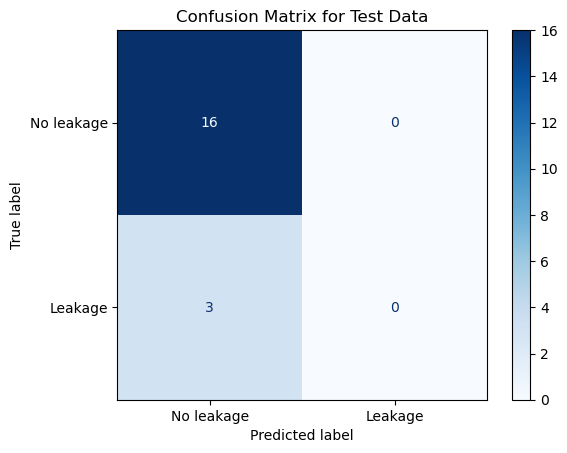

In [76]:
cm = confusion_matrix(y_test, test_preds_rf, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No leakage','Leakage'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Test Data")
plt.show()

In [81]:
probs = rf.predict_proba(X_test)[:, 1]
print(probs)

[0.34790306 0.34082146 0.39571712 0.16346012 0.24688743 0.01559745
 0.2769836  0.32131225 0.08863631 0.0757523  0.05067908 0.37294314
 0.0718019  0.30780187 0.33131386 0.02233333 0.26668603 0.10944858
 0.17882163]


In [96]:
probs = rf.predict_proba(X_train)[:, 1]
test_preds_rf = (probs >= 0.3).astype(int)

print(classification_report(y_train, test_preds_rf, zero_division=0))
print(confusion_matrix(y_train, test_preds_rf))

              precision    recall  f1-score   support

         0.0       1.00      0.92      0.96        36
         1.0       0.67      1.00      0.80         6

    accuracy                           0.93        42
   macro avg       0.83      0.96      0.88        42
weighted avg       0.95      0.93      0.93        42

[[33  3]
 [ 0  6]]


In [100]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=22)
cv

StratifiedKFold(n_splits=3, random_state=22, shuffle=True)

In [103]:
probs_test = rf.predict_proba(X_test)[:, 1]
test_preds_rf = (probs_test >= best_threshold).astype(int)
print('Train F1: ', f1_score(y_test, test_preds_rf, average='binary', zero_division=0))

Train F1:  0.36363636363636365


In [102]:
probs_train = rf.predict_proba(X_train)[:, 1]
train_preds_rf = (probs_train >= best_threshold).astype(int)
print('Train F1: ', f1_score(y_train, train_preds_rf, average='binary', zero_division=0))

Train F1:  0.6666666666666666


# Combined Plots for Thesis

## PCA

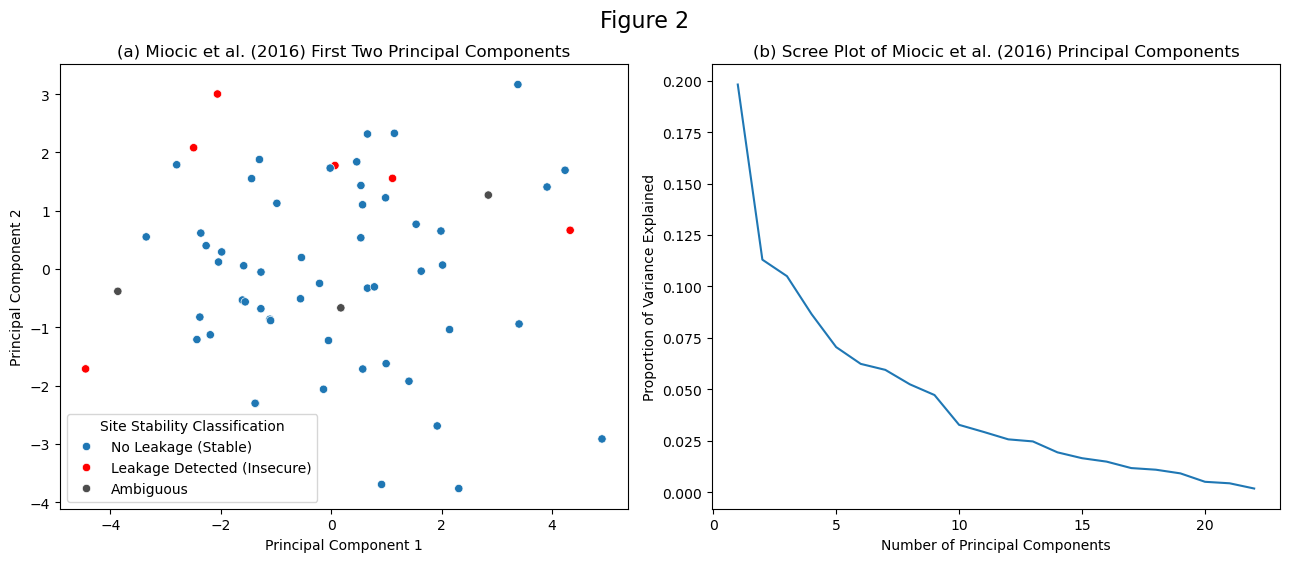

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# --- Left: PCA Scatter ---
sns.scatterplot(
    x=miocic_2d[:, 0],
    y=miocic_2d[:, 1],
    hue=hue,
    palette=palette,
    ax=axes[0] )
axes[0].set_title("(a) Miocic et al. (2016) First Two Principal Components")
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend(title='Site Stability Classification')

# --- Right: Scree Plot ---
x= np.arange(1, 23)
y = pca.explained_variance_ratio_
axes[1].plot(x, y)
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Proportion of Variance Explained')
axes[1].set_title('(b) Scree Plot of Miocic et al. (2016) Principal Components')

fig.subplots_adjust(wspace=0.95)
fig.suptitle("Figure 2", fontsize=16, y=0.93)
plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.savefig("Figure_2.png", dpi=300, bbox_inches='tight')
plt.show()